<a href="https://colab.research.google.com/github/keunsooyoon/Algorithms/blob/main/On_Structural_Criticality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

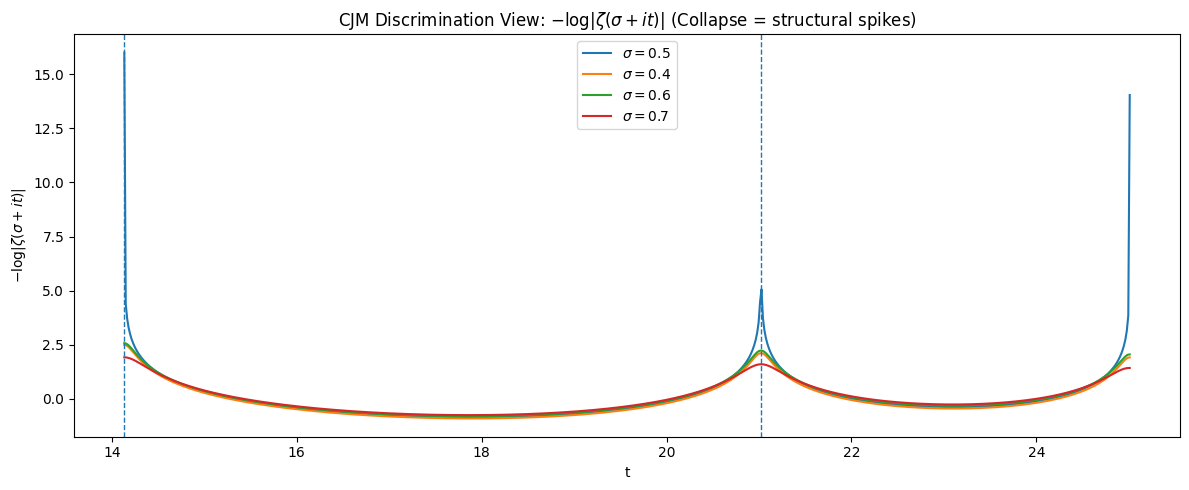

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpmath import zeta, mp

# -----------------------------
# 0) Numerical precision
# -----------------------------
# High precision is required to resolve sharp collapse near nontrivial zeros
mp.dps = 50  # Increase to 80–100 if higher fidelity is needed

# -----------------------------
# 1) CJM-style sampling of the zeta function
# -----------------------------
def sample_zeta_neglog(sigmas, t_values, eps=1e-50):
    """
    Sample -log(|zeta(sigma + i t)|) for multiple sigma values.

    Parameters:
        sigmas   : list of real parts (sigma values)
        t_values : array of imaginary parts (t values)
        eps      : small cutoff to avoid log(0)

    Returns:
        results[sigma] = numpy array of -log(|zeta(sigma+it)|)
    """
    results = {}

    for sigma in sigmas:
        values = []
        for t in t_values:
            s = mp.mpc(sigma, t)
            z = zeta(s)

            # Magnitude of zeta
            magnitude = abs(z)

            # Safeguard against numerical underflow near zeros
            magnitude_safe = max(magnitude, mp.mpf(eps))

            # Structural collapse metric (energy-like)
            values.append(float(-mp.log(magnitude_safe)))

        results[sigma] = np.array(values, dtype=float)

    return results

# -----------------------------
# 2) Experiment window
#    (Neighborhood of the first two nontrivial zeros)
# -----------------------------
t_start = 14.134725  # First nontrivial zero
t_end   = 25.010857  # Just beyond the second nontrivial zero
N = 700              # Resolution (higher = smoother, slower)

t_vals = np.linspace(t_start, t_end, N)

# Critical line + off-critical sigma shifts
sigmas = [0.5, 0.4, 0.6, 0.7]

data = sample_zeta_neglog(sigmas, t_vals)

# -----------------------------
# 3) Single CJM discrimination plot
# -----------------------------
plt.figure(figsize=(12, 5))

for sigma in sigmas:
    plt.plot(t_vals, data[sigma], label=fr'$\sigma={sigma}$')

# Known locations of the first two nontrivial zeros
plt.axvline(14.134725, linestyle='--', linewidth=1)
plt.axvline(21.022040, linestyle='--', linewidth=1)

plt.title(r"CJM Discrimination View: $-\log|\zeta(\sigma+it)|$ (Collapse = structural spikes)")
plt.xlabel("t")
plt.ylabel(r"$-\log|\zeta(\sigma+it)|$")
plt.legend()
plt.tight_layout()
plt.show()


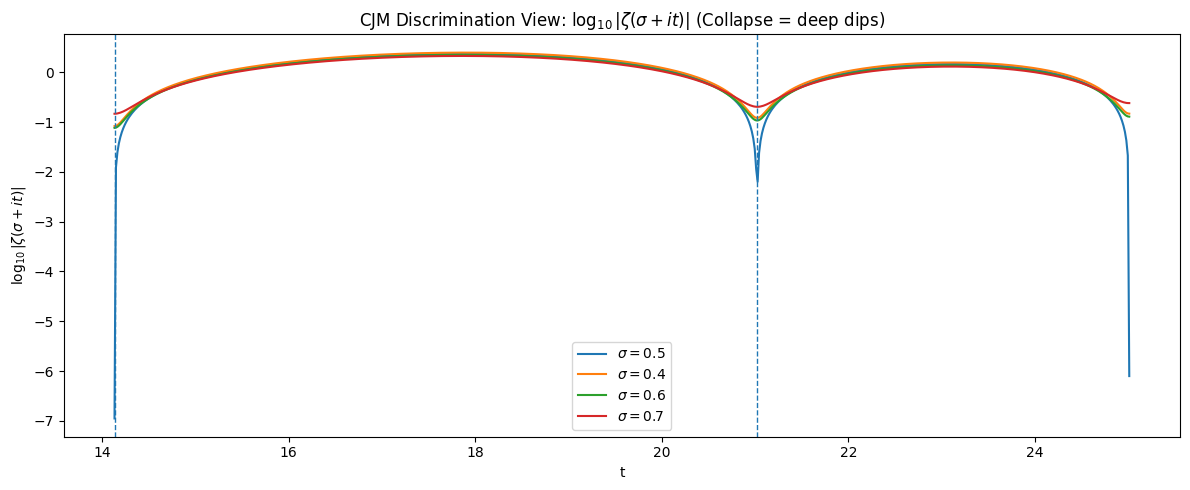

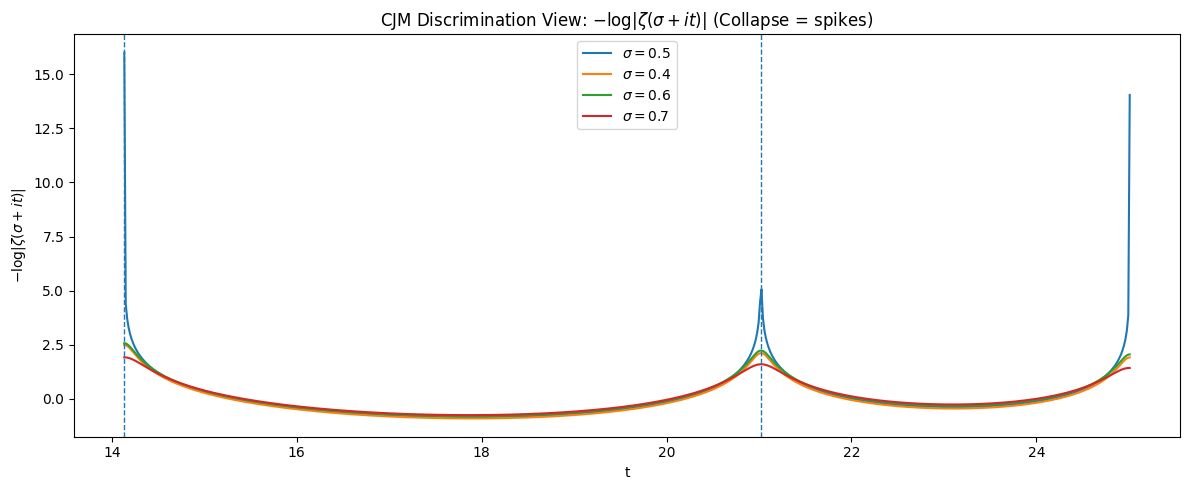

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpmath import zeta, mp

# -----------------------------
# 0) Precision
# -----------------------------
mp.dps = 50  # 필요하면 80~100까지 올려도 됨

# -----------------------------
# 1) CJM-style sampling of zeta
# -----------------------------
def sample_zeta_abs_log_metrics(sigmas, t_values, eps=1e-50):
    """
    Returns:
      metrics[sigma] = {
        'abs': |zeta(sigma+it)|,
        'log10abs': log10(|zeta|),
        'neglogabs': -log(|zeta|)
      }
    """
    metrics = {}
    for sigma in sigmas:
        abs_list = []
        log10_list = []
        neglog_list = []

        for t in t_values:
            s = mp.mpc(sigma, t)
            z = zeta(s)
            a = abs(z)

            # guard for near-zero to avoid -inf / +inf blowing up plots
            a_safe = max(a, mp.mpf(eps))

            abs_list.append(float(a))
            log10_list.append(float(mp.log10(a_safe)))
            neglog_list.append(float(-mp.log(a_safe)))

        metrics[sigma] = {
            "abs": np.array(abs_list, dtype=float),
            "log10abs": np.array(log10_list, dtype=float),
            "neglogabs": np.array(neglog_list, dtype=float),
        }
    return metrics

# -----------------------------
# 2) Experiment window (first two nontrivial zeros neighborhood)
# -----------------------------
t_start = 14.134725
t_end   = 25.010857
N = 700  # 해상도 (늘리면 더 매끈하지만 느려짐)
t_vals = np.linspace(t_start, t_end, N)

sigmas = [0.5, 0.4, 0.6, 0.7]  # critical + multi sigma-shifts
M = sample_zeta_abs_log_metrics(sigmas, t_vals)

# -----------------------------
# 3) Plot A: log10(|zeta|)  (collapse -> deep negative dips at zeros)
# -----------------------------
plt.figure(figsize=(12, 5))
for sigma in sigmas:
    plt.plot(t_vals, M[sigma]["log10abs"], label=fr'$\sigma={sigma}$')
plt.axvline(14.134725, linestyle="--", linewidth=1)  # 1st zero (known)
plt.axvline(21.022040, linestyle="--", linewidth=1)  # 2nd zero (known)
plt.title(r"CJM Discrimination View: $\log_{10}|\zeta(\sigma+it)|$ (Collapse = deep dips)")
plt.xlabel("t")
plt.ylabel(r"$\log_{10}|\zeta(\sigma+it)|$")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Plot B: -log(|zeta|)  (collapse -> tall positive spikes at zeros)
# -----------------------------
plt.figure(figsize=(12, 5))
for sigma in sigmas:
    plt.plot(t_vals, M[sigma]["neglogabs"], label=fr'$\sigma={sigma}$')
plt.axvline(14.134725, linestyle="--", linewidth=1)
plt.axvline(21.022040, linestyle="--", linewidth=1)
plt.title(r"CJM Discrimination View: $-\log|\zeta(\sigma+it)|$ (Collapse = spikes)")
plt.xlabel("t")
plt.ylabel(r"$-\log|\zeta(\sigma+it)|$")
plt.legend()
plt.tight_layout()
plt.show()


Computing real zeta values for 2D figure...

=== Physical Discriminator Summary (2D, Real zeta) ===
sigma=0.45 | Var_t(Z)=0.778696 | StabilityScore=1.284198
sigma=0.50 | Var_t(Z)=0.911173 | StabilityScore=1.097486
sigma=0.55 | Var_t(Z)=0.778671 | StabilityScore=1.284240

Best stability by Var_t criterion: sigma=0.55


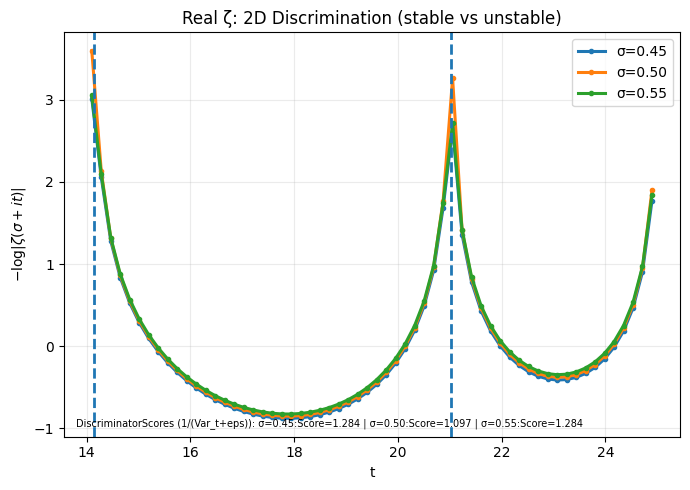

In [5]:
# ============================================================
# Fig A (2D): Real zeta-based discrimination + stability score
# Independent Colab cell (run as-is)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from mpmath import mp, zeta

# ----------------------------
# Configuration
# ----------------------------
mp.dps = 35  # Increase if you want smoother/safer values (slower)
EPS_MAG = 1e-40  # Prevent log(0)
EPS_SCORE = 1e-12

# Window (keep small for fast Colab runtime)
t_vals = np.linspace(14.1, 24.9, 60)          # t-grid
sigma_vals = np.array([0.45, 0.50, 0.55])     # 3 curves for 2D figure

# Known early zeros on critical line (for visual markers only)
zero_markers = [14.134725, 21.022040]

# ----------------------------
# Helper: compute Z(sigma,t) = -log|zeta(sigma+it)|
# ----------------------------
def compute_neglog_zeta(sigmas, t_grid):
    Z = np.zeros((len(sigmas), len(t_grid)), dtype=float)
    for i, sigma in enumerate(sigmas):
        for j, t in enumerate(t_grid):
            s = mp.mpc(float(sigma), float(t))
            mag = float(abs(zeta(s)))
            Z[i, j] = -np.log(max(mag, EPS_MAG))
    return Z

print("Computing real zeta values for 2D figure...")
Z = compute_neglog_zeta(sigma_vals, t_vals)

# ----------------------------
# Define a simple "physical discriminator score"
# Idea: more "stable" curve => smaller variance over t.
# StabilityScore = 1 / (Var_t(Z) + eps)
# ----------------------------
var_t = np.var(Z, axis=1)                      # Var over t for each sigma
stability_score = 1.0 / (var_t + EPS_SCORE)    # Higher is "more stable"

best_idx = int(np.argmax(stability_score))
best_sigma = sigma_vals[best_idx]

print("\n=== Physical Discriminator Summary (2D, Real zeta) ===")
for i, sigma in enumerate(sigma_vals):
    print(f"sigma={sigma:.2f} | Var_t(Z)={var_t[i]:.6f} | StabilityScore={stability_score[i]:.6f}")
print(f"\nBest stability by Var_t criterion: sigma={best_sigma:.2f}")

# ----------------------------
# Plot (2D)
# ----------------------------
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)

for i, sigma in enumerate(sigma_vals):
    ax.plot(t_vals, Z[i, :], marker='o', markersize=3, linewidth=2.2, label=f'σ={sigma:.2f}')

for x0 in zero_markers:
    ax.axvline(x0, linestyle='--', linewidth=2)

ax.set_title("Real ζ: 2D Discrimination (stable vs unstable)")
ax.set_xlabel("t")
ax.set_ylabel(r"$-\log|\zeta(\sigma+it)|$")
ax.grid(alpha=0.25)
ax.legend(loc="best")

# Add a one-line discriminator score into the figure itself
score_text = " | ".join([f"σ={sigma_vals[i]:.2f}:Score={stability_score[i]:.3f}" for i in range(len(sigma_vals))])
ax.text(0.02, 0.02, f"DiscriminatorScores (1/(Var_t+eps)): {score_text}",
        transform=ax.transAxes, fontsize=7, va='bottom')

plt.tight_layout()
plt.show()


Computing real zeta surface...

=== Physical Discriminator Summary (3D, Real ζ) ===
Best stability by Var_t criterion: sigma=0.550000 | Var_t(Z)=0.774572 | StabilityScore=1.291036
RidgeAdherence (mean |sigma_argmax(t) - 0.5|): 0.045833


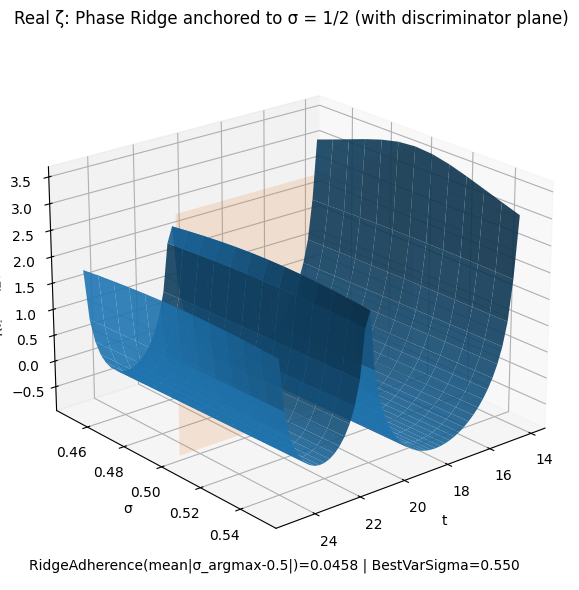

In [21]:
# ============================================================
# Fig B (3D): Real zeta surface + sigma=1/2 plane + ridge metrics
# Independent Colab cell (run as-is)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from mpmath import mp, zeta
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ----------------------------
# Configuration
# ----------------------------
mp.dps = 35
EPS_MAG = 1e-40
EPS_SCORE = 1e-12

# A slightly denser grid than your 8x30 is still OK if mp.dps moderate
t_vals = np.linspace(14.1, 24.9, 50)
sigma_vals = np.linspace(0.45, 0.55, 13)  # centered around 0.5 for ridge visualization

# ----------------------------
# Helper: compute Z(sigma,t) = -log|zeta(sigma+it)|
# ----------------------------
def compute_neglog_zeta_grid(sigmas, t_grid):
    Z = np.zeros((len(sigmas), len(t_grid)), dtype=float)
    for i, sigma in enumerate(sigmas):
        for j, t in enumerate(t_grid):
            s = mp.mpc(float(sigma), float(t))
            mag = float(abs(zeta(s)))
            Z[i, j] = -np.log(max(mag, EPS_MAG))
    return Z

print("Computing real zeta surface...")
Z = compute_neglog_zeta_grid(sigma_vals, t_vals)

# ----------------------------
# Ridge detection + "Ridge Adherence" metric
# For each t, find sigma index that maximizes Z(sigma,t),
# then measure mean |sigma_argmax(t) - 0.5|.
# Lower is "more adherent to the critical plane".
# ----------------------------
argmax_sigma_idx = np.argmax(Z, axis=0)  # over sigma for each t
sigma_argmax = sigma_vals[argmax_sigma_idx]
ridge_adherence = float(np.mean(np.abs(sigma_argmax - 0.5)))

# ----------------------------
# A stability-style metric across sigmas (optional print)
# Using Var_t for each sigma line (same as 2D logic)
# ----------------------------
var_t = np.var(Z, axis=1)
stability_score = 1.0 / (var_t + EPS_SCORE)
best_idx = int(np.argmax(stability_score))
best_sigma = float(sigma_vals[best_idx])

print("\n=== Physical Discriminator Summary (3D, Real ζ) ===")
print(f"Best stability by Var_t criterion: sigma={best_sigma:.6f} | Var_t(Z)={var_t[best_idx]:.6f} | StabilityScore={stability_score[best_idx]:.6f}")
print(f"RidgeAdherence (mean |sigma_argmax(t) - 0.5|): {ridge_adherence:.6f}")

# ----------------------------
# Plot (3D surface) + sigma=1/2 plane
# IMPORTANT: Avoid fragile LaTeX in titles; use plain Unicode where possible.
# ----------------------------
T, S = np.meshgrid(t_vals, sigma_vals)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')

# Main surface
surf = ax.plot_surface(T, S, Z, alpha=0.90, rstride=1, cstride=1)

# Contours (optional but helps perception)
ax.contour(T, S, Z, levels=7, alpha=0.55, linewidths=0.6)

# Add a thin translucent vertical plane at sigma = 0.5
zmin = float(np.min(Z))
zmax = float(np.max(Z))
z_plane = np.linspace(zmin, zmax, 2)
T_plane, Z_plane = np.meshgrid(t_vals, z_plane)
S_plane = 0.5 * np.ones_like(T_plane)

ax.plot_surface(T_plane, S_plane, Z_plane, alpha=0.15)

# Labels/titles (NO broken \frac12)
ax.set_title("Real ζ: Phase Ridge anchored to σ = 1/2 (with discriminator plane)")
ax.set_xlabel("t")
ax.set_ylabel("σ")
ax.set_zlabel(r"$-\log|\zeta(\sigma+it)|$")

# View angle
ax.view_init(elev=22, azim=50)

# Put the metric on the plot
metric_str = f"RidgeAdherence(mean|σ_argmax-0.5|)={ridge_adherence:.4f} | BestVarSigma={best_sigma:.3f}"
ax.text2D(0.02, 0.02, metric_str, transform=ax.transAxes, fontsize=10)

plt.tight_layout()
plt.show()
